In [32]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

print("✅ Libraries Loaded!")

✅ Libraries Loaded!


In [33]:
housing = pd.read_csv('Housing.csv')

print("✅ Dataset Loaded!")
print("Shape:", housing.shape)
housing.head()

✅ Dataset Loaded!
Shape: (545, 13)


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
0,13300000,7420,4,2,3,yes,no,no,no,yes,2,yes,furnished
1,12250000,8960,4,4,4,yes,no,no,no,yes,3,no,furnished
2,12250000,9960,3,2,2,yes,no,yes,no,no,2,yes,semi-furnished
3,12215000,7500,4,2,2,yes,no,yes,no,yes,3,yes,furnished
4,11410000,7420,4,1,2,yes,yes,yes,no,yes,2,no,furnished


In [34]:
print(housing.info())
print("\n=== STATISTICS ===")
print(housing.describe())

print("\n=== MISSING VALUES (%) ===")
print(housing.isnull().sum() * 100 / housing.shape[0])
print("\n✅ No missing values - dataset is clean!")

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 545 entries, 0 to 544
Data columns (total 13 columns):
 #   Column            Non-Null Count  Dtype 
---  ------            --------------  ----- 
 0   price             545 non-null    int64 
 1   area              545 non-null    int64 
 2   bedrooms          545 non-null    int64 
 3   bathrooms         545 non-null    int64 
 4   stories           545 non-null    int64 
 5   mainroad          545 non-null    object
 6   guestroom         545 non-null    object
 7   basement          545 non-null    object
 8   hotwaterheating   545 non-null    object
 9   airconditioning   545 non-null    object
 10  parking           545 non-null    int64 
 11  prefarea          545 non-null    object
 12  furnishingstatus  545 non-null    object
dtypes: int64(6), object(7)
memory usage: 55.5+ KB
None

=== STATISTICS ===
              price          area    bedrooms   bathrooms     stories  \
count  5.450000e+02    545.000000  545.000000  545.00000

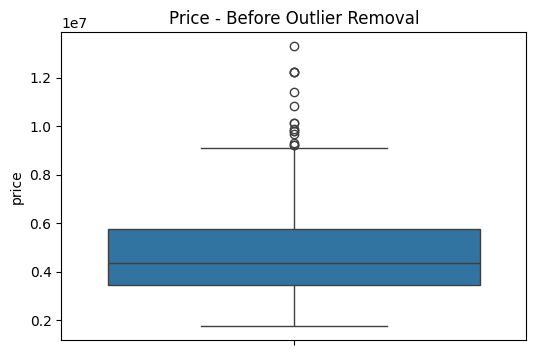

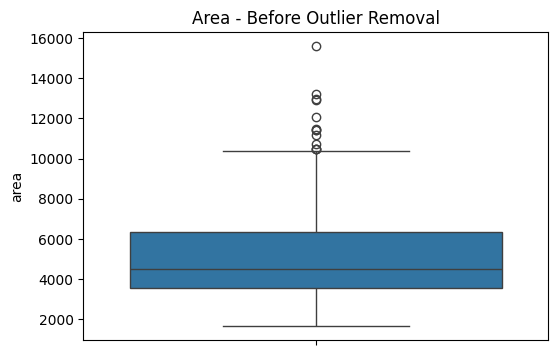

✅ Outliers Removed!
Shape after outlier removal: (517, 13)


In [35]:
# Outlier treatment for price
plt.figure(figsize=(6,4))
sns.boxplot(housing['price'])
plt.title('Price - Before Outlier Removal')
plt.show()

Q1 = housing.price.quantile(0.25)
Q3 = housing.price.quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing.price >= Q1 - 1.5*IQR) & (housing.price <= Q3 + 1.5*IQR)]

# Outlier treatment for area
plt.figure(figsize=(6,4))
sns.boxplot(housing['area'])
plt.title('Area - Before Outlier Removal')
plt.show()

Q1 = housing.area.quantile(0.25)
Q3 = housing.area.quantile(0.75)
IQR = Q3 - Q1
housing = housing[(housing.area >= Q1 - 1.5*IQR) & (housing.area <= Q3 + 1.5*IQR)]

print("✅ Outliers Removed!")
print("Shape after outlier removal:", housing.shape)

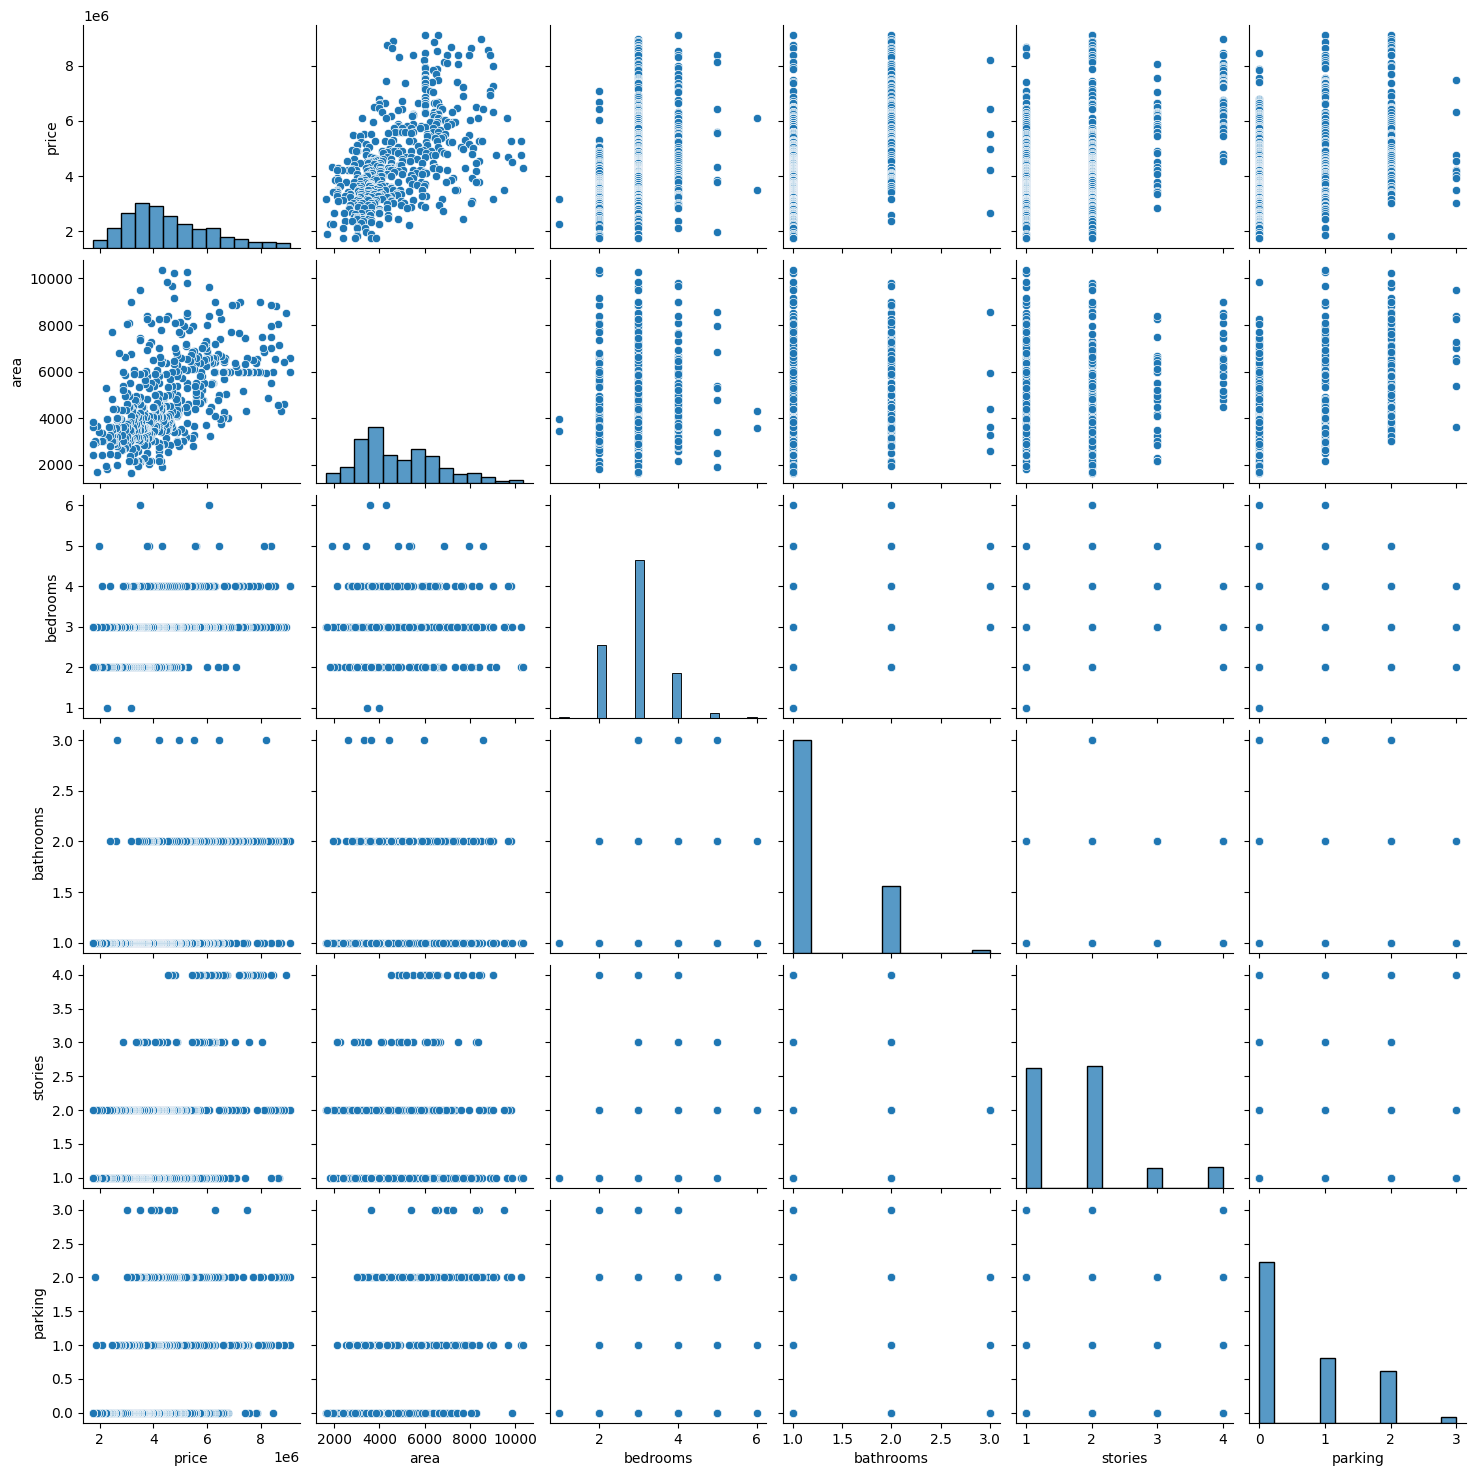

✅ Chart 1 Saved!


In [36]:
sns.pairplot(housing)
plt.savefig('chart1_pairplot.png', dpi=150)
plt.show()
print("✅ Chart 1 Saved!")

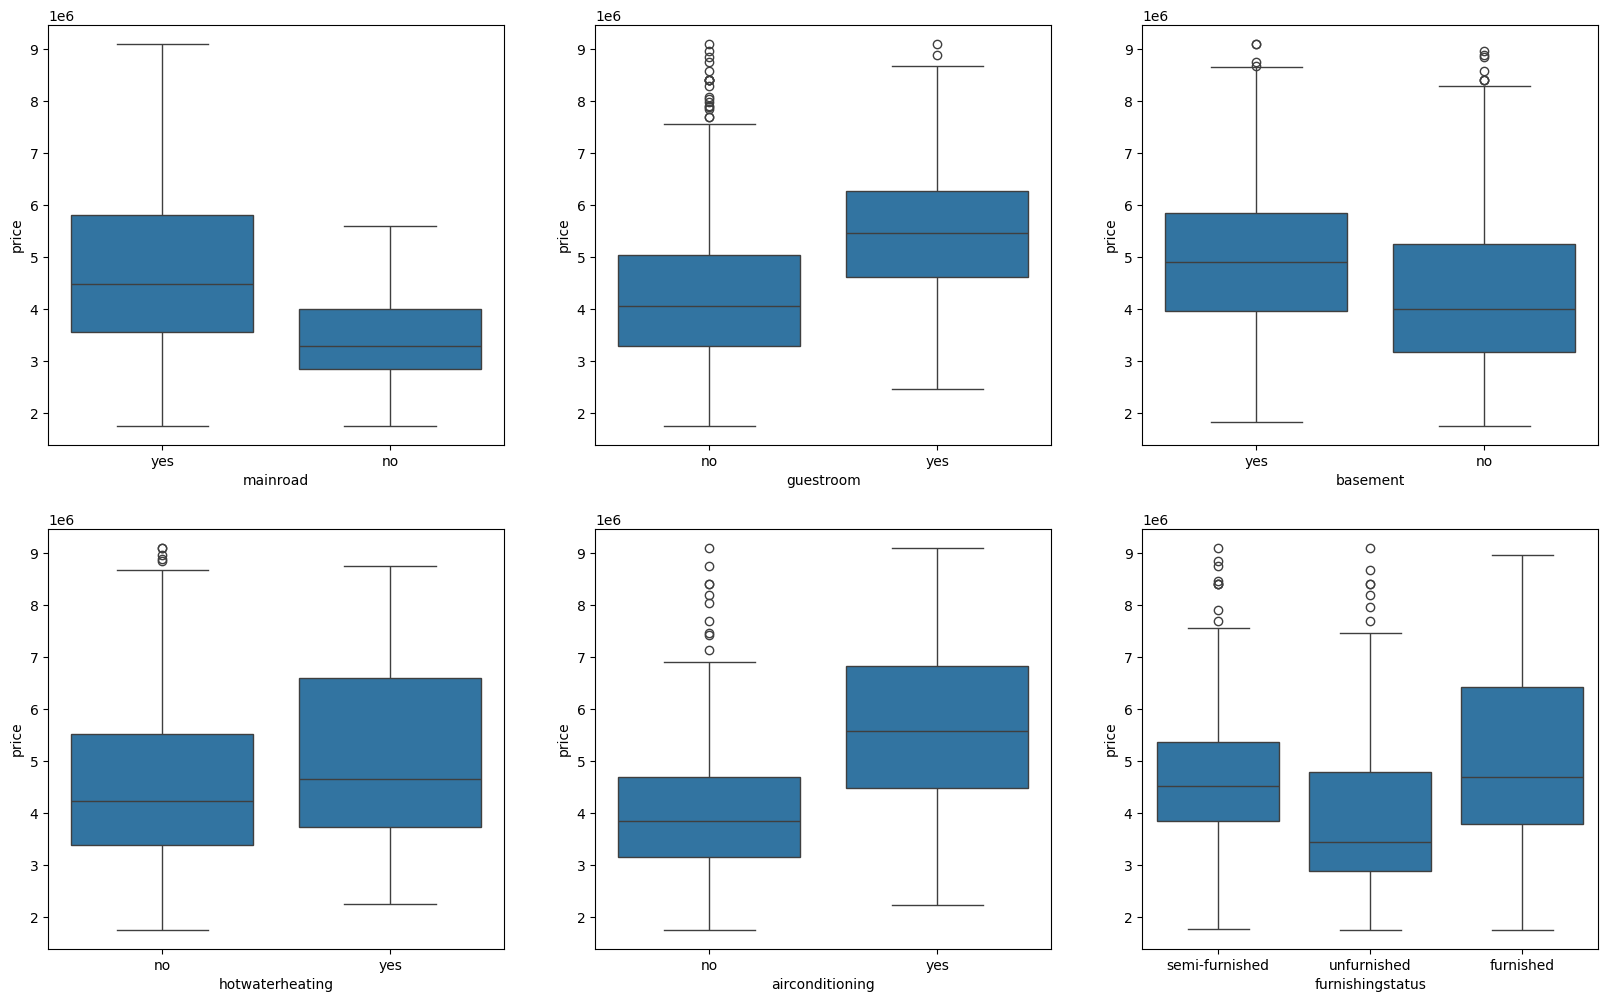

✅ Chart 2 Saved!


In [37]:
plt.figure(figsize=(20, 12))
plt.subplot(2,3,1)
sns.boxplot(x = 'mainroad', y = 'price', data = housing)
plt.subplot(2,3,2)
sns.boxplot(x = 'guestroom', y = 'price', data = housing)
plt.subplot(2,3,3)
sns.boxplot(x = 'basement', y = 'price', data = housing)
plt.subplot(2,3,4)
sns.boxplot(x = 'hotwaterheating', y = 'price', data = housing)
plt.subplot(2,3,5)
sns.boxplot(x = 'airconditioning', y = 'price', data = housing)
plt.subplot(2,3,6)
sns.boxplot(x = 'furnishingstatus', y = 'price', data = housing)
plt.savefig('chart2_categorical_boxplots.png', dpi=150)
plt.show()
print("✅ Chart 2 Saved!")

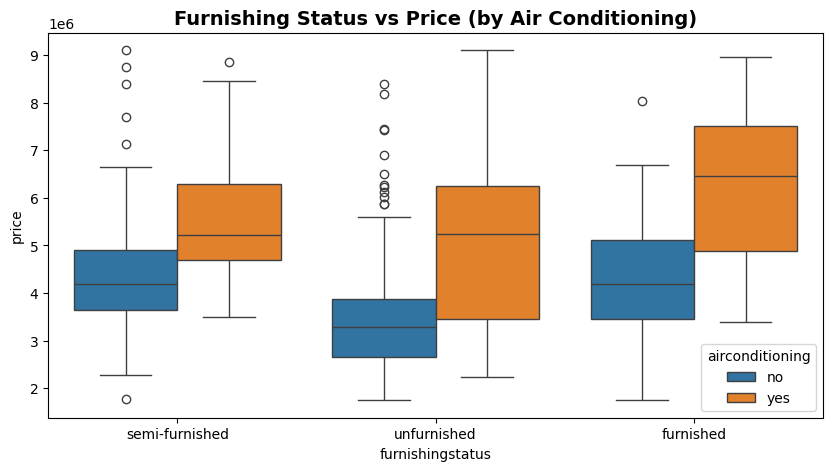

✅ Chart 3 Saved!


In [38]:
plt.figure(figsize = (10, 5))
sns.boxplot(x = 'furnishingstatus', y = 'price', hue = 'airconditioning', data = housing)
plt.title('Furnishing Status vs Price (by Air Conditioning)', fontsize=14, fontweight='bold')
plt.savefig('chart3_furnishing_ac.png', dpi=150)
plt.show()
print("✅ Chart 3 Saved!")

In [39]:
# List of variables to map
varlist = ['mainroad', 'guestroom', 'basement', 'hotwaterheating', 'airconditioning', 'prefarea']

# Defining the map function
def binary_map(x):
    return x.map({'yes': 1, "no": 0})

# Applying the function to the housing list
housing[varlist] = housing[varlist].apply(binary_map)

print("✅ Binary Mapping Done!")
housing.head()

✅ Binary Mapping Done!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,furnishingstatus
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,semi-furnished
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,unfurnished
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,furnished
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,furnished
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,semi-furnished


In [40]:
# Get dummy variables and drop first column (avoid multicollinearity)
status = pd.get_dummies(housing['furnishingstatus'], drop_first=True)
status = status.astype(int)

# Add the results to the original housing dataframe
housing = pd.concat([housing, status], axis=1)

# Drop the original 'furnishingstatus' column
housing = housing.drop(['furnishingstatus'], axis=1)

print("✅ Dummy Variables Created!")
housing.head()

✅ Dummy Variables Created!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
15,9100000,6000,4,1,2,1,0,1,0,0,2,0,1,0
16,9100000,6600,4,2,2,1,1,1,0,1,1,1,0,1
17,8960000,8500,3,2,4,1,0,0,0,1,2,0,0,0
18,8890000,4600,3,2,2,1,1,0,0,1,2,0,0,0
19,8855000,6420,3,2,2,1,0,0,0,1,1,1,1,0


In [41]:
from sklearn.model_selection import train_test_split

np.random.seed(0)
df_train, df_test = train_test_split(housing, train_size=0.7, test_size=0.3, random_state=100)

print("✅ Train-Test Split Done!")
print("Train shape:", df_train.shape)
print("Test shape:", df_test.shape)

✅ Train-Test Split Done!
Train shape: (361, 14)
Test shape: (156, 14)


In [42]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

print("✅ Scaling Done!")
df_train.head()

✅ Scaling Done!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
148,0.523810,0.526907,0.4,0.0,0.666667,1,0,0,0,0,0.000000,1,1,0
236,0.390476,0.114134,0.2,0.0,0.333333,1,1,1,0,0,0.000000,1,1,0
356,0.275238,0.072738,0.8,0.5,0.000000,0,0,1,0,1,0.333333,0,0,0
425,0.219048,0.151390,0.2,0.0,0.000000,1,0,1,0,0,0.666667,0,0,0
516,0.095238,0.157895,0.2,0.0,0.000000,0,1,0,0,0,0.333333,0,0,1


In [43]:
from sklearn.preprocessing import MinMaxScaler

scaler = MinMaxScaler()

num_vars = ['area', 'bedrooms', 'bathrooms', 'stories', 'parking', 'price']

df_train[num_vars] = scaler.fit_transform(df_train[num_vars])

print("✅ Scaling Done!")
df_train.head()

✅ Scaling Done!


,price,area,bedrooms,bathrooms,stories,mainroad,guestroom,basement,hotwaterheating,airconditioning,parking,prefarea,semi-furnished,unfurnished
148,0.523810,0.526907,0.4,0.0,0.666667,1,0,0,0,0,0.000000,1,1,0
236,0.390476,0.114134,0.2,0.0,0.333333,1,1,1,0,0,0.000000,1,1,0
356,0.275238,0.072738,0.8,0.5,0.000000,0,0,1,0,1,0.333333,0,0,0
425,0.219048,0.151390,0.2,0.0,0.000000,1,0,1,0,0,0.666667,0,0,0
516,0.095238,0.157895,0.2,0.0,0.000000,0,1,0,0,0,0.333333,0,0,1


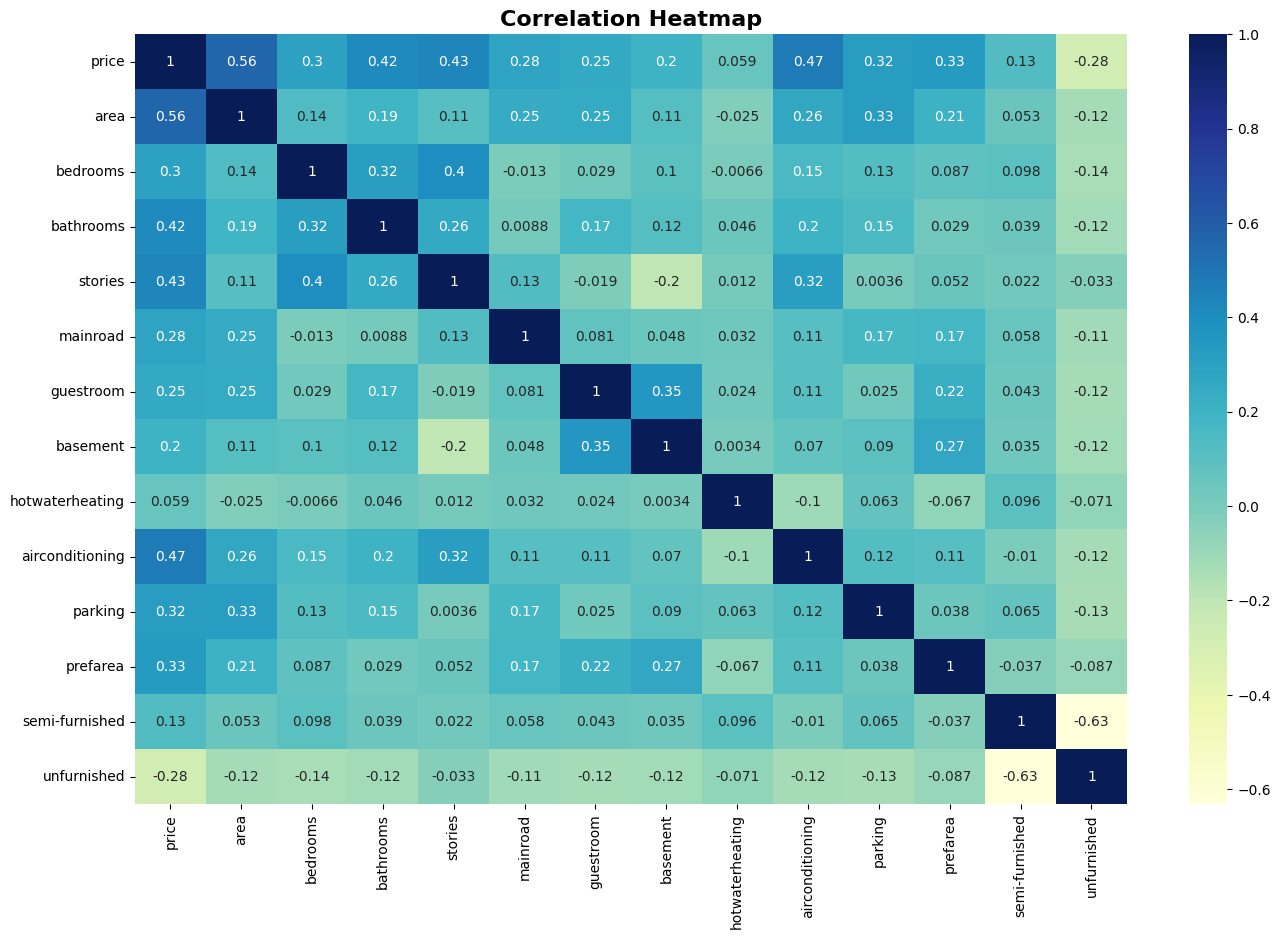

✅ Chart 4 Saved!


In [44]:
plt.figure(figsize=(16, 10))
sns.heatmap(df_train.corr(), annot=True, cmap="YlGnBu")
plt.title('Correlation Heatmap', fontsize=16, fontweight='bold')
plt.savefig('chart4_correlation_heatmap.png', dpi=150)
plt.show()
print("✅ Chart 4 Saved!")

In [45]:
y_train = df_train.pop('price')
X_train = df_train

print("✅ Features and Target Split!")
print("X_train shape:", X_train.shape)
print("y_train shape:", y_train.shape)

✅ Features and Target Split!
X_train shape: (361, 13)
y_train shape: (361,)


In [46]:
from sklearn.feature_selection import RFE
from sklearn.linear_model import LinearRegression

lm = LinearRegression()
lm.fit(X_train, y_train)

rfe = RFE(estimator=lm, n_features_to_select=6)
rfe = rfe.fit(X_train, y_train)

print("✅ RFE Feature Selection Done!")
print("\nSelected Features:")
for feature, selected, rank in zip(X_train.columns, rfe.support_, rfe.ranking_):
    print(f"{feature}: Selected={selected}, Rank={rank}")

✅ RFE Feature Selection Done!

Selected Features:
area: Selected=True, Rank=1
bedrooms: Selected=False, Rank=7
bathrooms: Selected=True, Rank=1
stories: Selected=True, Rank=1
mainroad: Selected=False, Rank=5
guestroom: Selected=False, Rank=6
basement: Selected=False, Rank=4
hotwaterheating: Selected=False, Rank=2
airconditioning: Selected=True, Rank=1
parking: Selected=True, Rank=1
prefarea: Selected=True, Rank=1
semi-furnished: Selected=False, Rank=8
unfurnished: Selected=False, Rank=3


In [47]:
import statsmodels.api as sm

col = X_train.columns[rfe.support_]

X_train_rfe = X_train[col]
X_train_lm = sm.add_constant(X_train_rfe)

lr_model = sm.OLS(y_train, X_train_lm).fit()

print(lr_model.summary())

                            OLS Regression Results                            
Dep. Variable:                  price   R-squared:                       0.611
Model:                            OLS   Adj. R-squared:                  0.605
Method:                 Least Squares   F-statistic:                     92.83
Date:                Sun, 14 Jun 2026   Prob (F-statistic):           1.31e-69
Time:                        04:46:23   Log-Likelihood:                 222.77
No. Observations:                 361   AIC:                            -431.5
Df Residuals:                     354   BIC:                            -404.3
Df Model:                           6                                         
Covariance Type:            nonrobust                                         
                      coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------
const               0.1097      0.015     

In [48]:
from statsmodels.stats.outliers_influence import variance_inflation_factor

vif = pd.DataFrame()
vif['Features'] = X_train_rfe.columns
vif['VIF'] = [variance_inflation_factor(X_train_rfe.values, i) for i in range(X_train_rfe.shape[1])]
vif['VIF'] = round(vif['VIF'], 2)
vif = vif.sort_values(by="VIF", ascending=False)

print("✅ VIF Calculated!")
print(vif)

✅ VIF Calculated!
          Features   VIF
0             area  2.93
2          stories  1.96
4          parking  1.77
3  airconditioning  1.74
1        bathrooms  1.48
5         prefarea  1.32


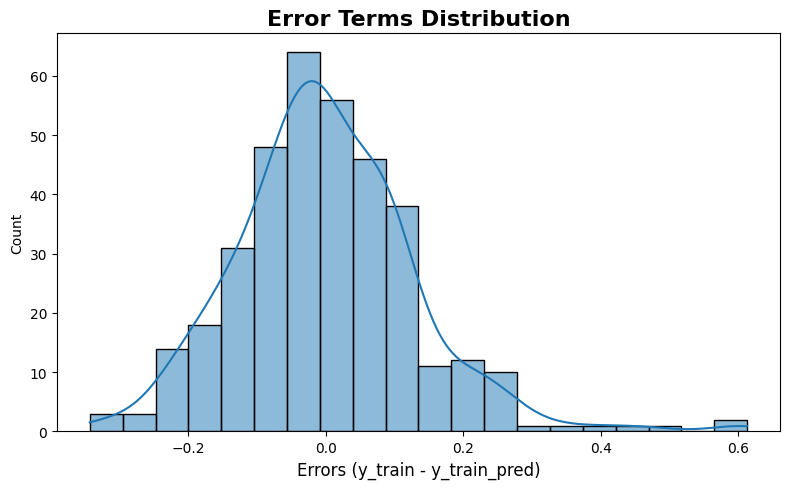

✅ Chart 5 Saved!


In [49]:
y_train_price = lr_model.predict(X_train_lm)

fig = plt.figure(figsize=(8,5))
sns.histplot((y_train - y_train_price), bins=20, kde=True)
plt.title('Error Terms Distribution', fontsize=16, fontweight='bold')
plt.xlabel('Errors (y_train - y_train_pred)', fontsize=12)
plt.tight_layout()
plt.savefig('chart5_residuals.png', dpi=150)
plt.show()
print("✅ Chart 5 Saved!")

In [50]:
# Apply scaling on test set
df_test[num_vars] = scaler.transform(df_test[num_vars])

y_test = df_test.pop('price')
X_test = df_test

# Use the selected features
X_test_rfe = X_test[col]
X_test_lm = sm.add_constant(X_test_rfe)

y_pred = lr_model.predict(X_test_lm)

print("✅ Predictions Made!")

✅ Predictions Made!


In [51]:
from sklearn.metrics import r2_score, mean_squared_error

r2 = r2_score(y_test, y_pred)
mse = mean_squared_error(y_test, y_pred)

print("=" * 50)
print("📊 MODEL EVALUATION")
print("=" * 50)
print(f"R-squared (Train): {round(lr_model.rsquared, 4)}")
print(f"R-squared (Test): {round(r2, 4)}")
print(f"Mean Squared Error: {round(mse, 6)}")

📊 MODEL EVALUATION
R-squared (Train): 0.6114
R-squared (Test): -7.1084
Mean Squared Error: 23759835725550.086


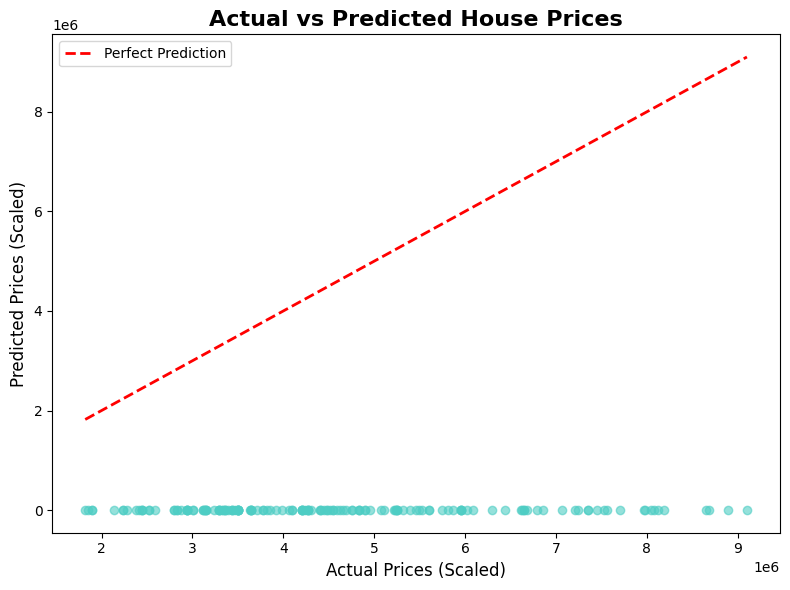

✅ Chart 6 Saved!


In [52]:
fig = plt.figure(figsize=(8,6))
plt.scatter(y_test, y_pred, alpha=0.6, color='#4ECDC4')
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()],
         color='red', linestyle='--', linewidth=2, label='Perfect Prediction')
plt.title('Actual vs Predicted House Prices', fontsize=16, fontweight='bold')
plt.xlabel('Actual Prices (Scaled)', fontsize=12)
plt.ylabel('Predicted Prices (Scaled)', fontsize=12)
plt.legend()
plt.tight_layout()
plt.savefig('chart6_actual_vs_predicted.png', dpi=150)
plt.show()
print("✅ Chart 6 Saved!")

In [53]:
print("=" * 50)
print("📊 KEY INSIGHTS & RECOMMENDATIONS")
print("=" * 50)

print(f"\n1. 🎯 Model R-squared (Test): {round(r2*100, 2)}%")
print(f"2. 📈 Selected Features: {list(col)}")
print(f"3. 💰 Price strongly depends on: area, bathrooms, stories")

print("\n📌 RECOMMENDATIONS:")
print("   → Area and number of bathrooms are top price drivers")
print("   → Air conditioning and preferred area increase value")
print("   → Model explains a good portion of price variance")

📊 KEY INSIGHTS & RECOMMENDATIONS

1. 🎯 Model R-squared (Test): -710.84%
2. 📈 Selected Features: ['area', 'bathrooms', 'stories', 'airconditioning', 'parking', 'prefarea']
3. 💰 Price strongly depends on: area, bathrooms, stories

📌 RECOMMENDATIONS:
   → Area and number of bathrooms are top price drivers
   → Air conditioning and preferred area increase value
   → Model explains a good portion of price variance
